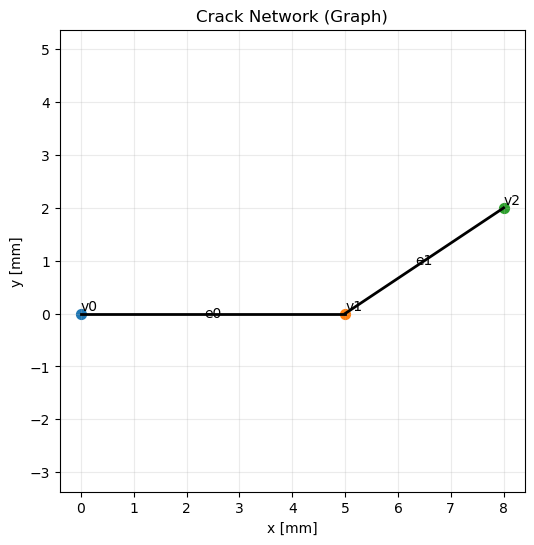

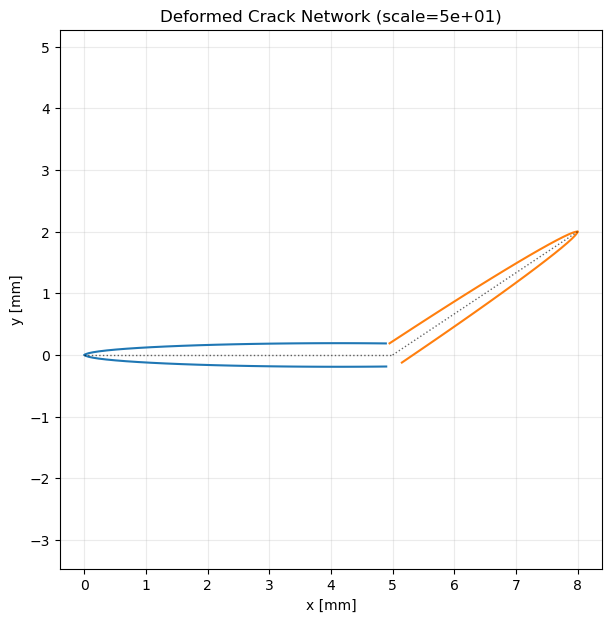

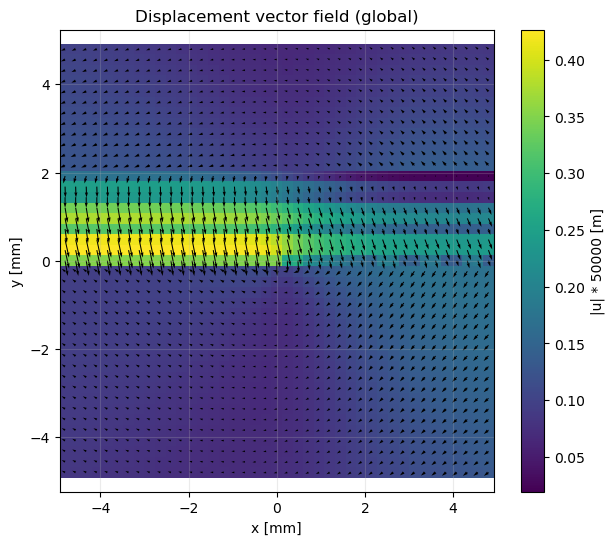

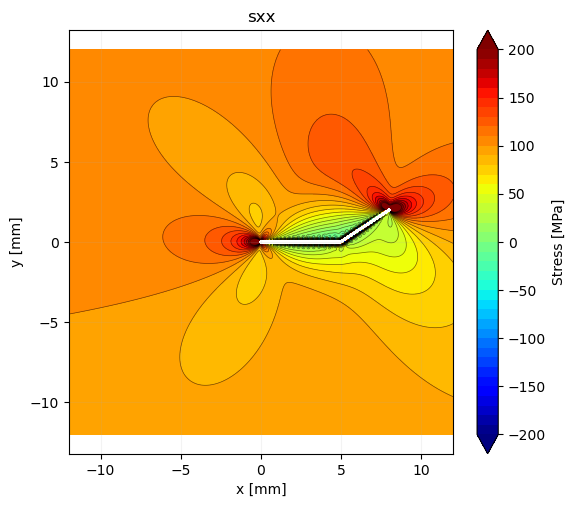

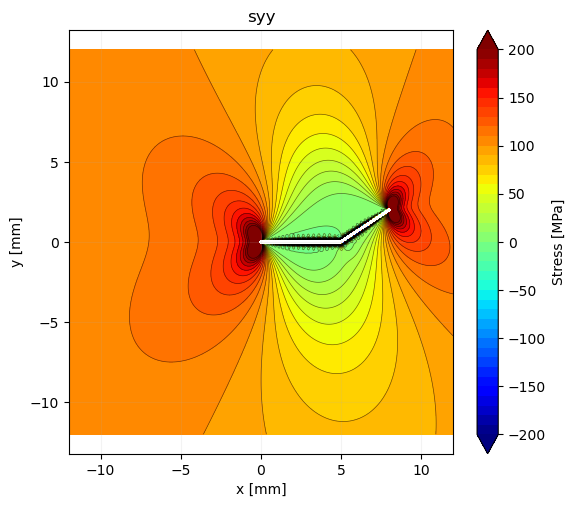

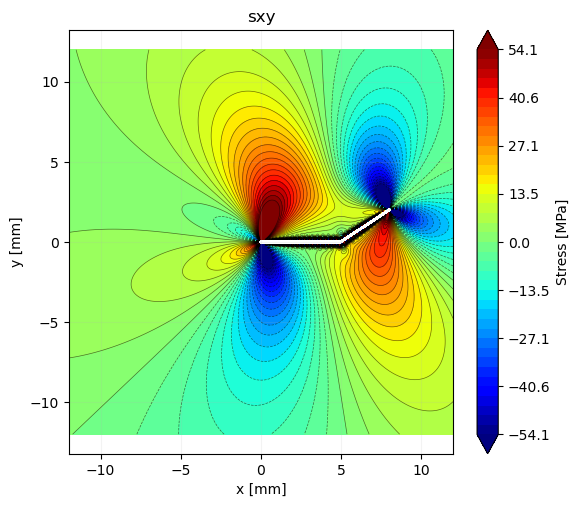

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1


In [ ]:
from pathlib import Path
import os, sys, importlib
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)
    
from preamble import *
enable_autoreload()
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1")
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 junction
    [1,   5.0*mm,  0*mm], # v1 upper-right
    [2,   8.0*mm, 2.0*mm], # v2 lower-right
    # [3,   5.0*mm, -4.0*mm], # v3 upper-left
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
    [1, 2],
    # [1, 3],
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="full",
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Deformed crack network
plotter.plot_deformed_network(scale=5e1, n_pts_per_edge=800, 
                              show_faces=True, cod_smooth_window=5)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


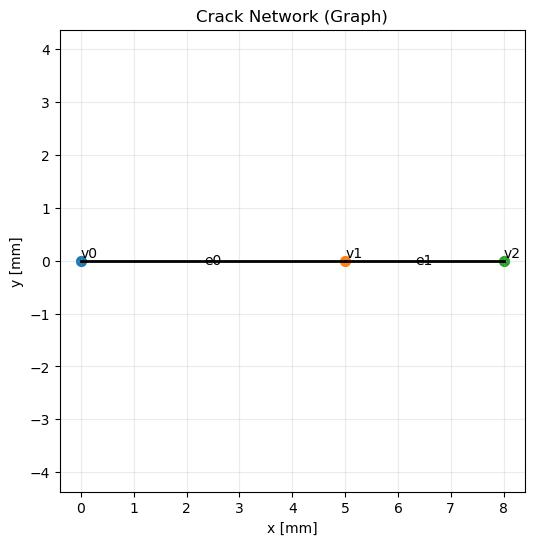

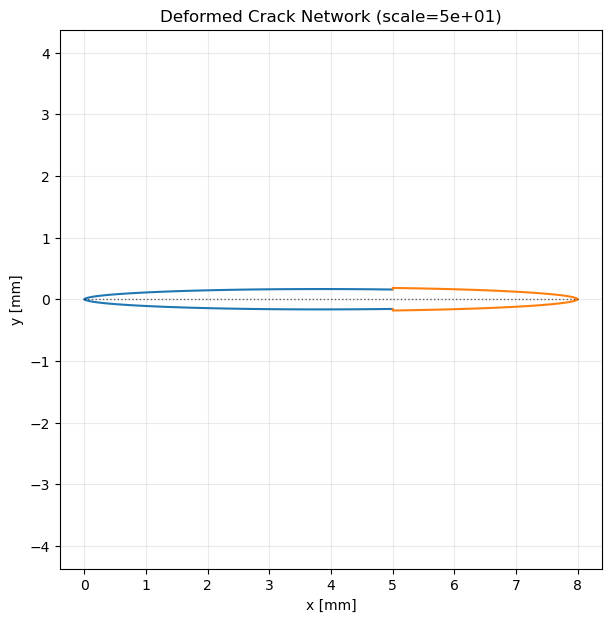

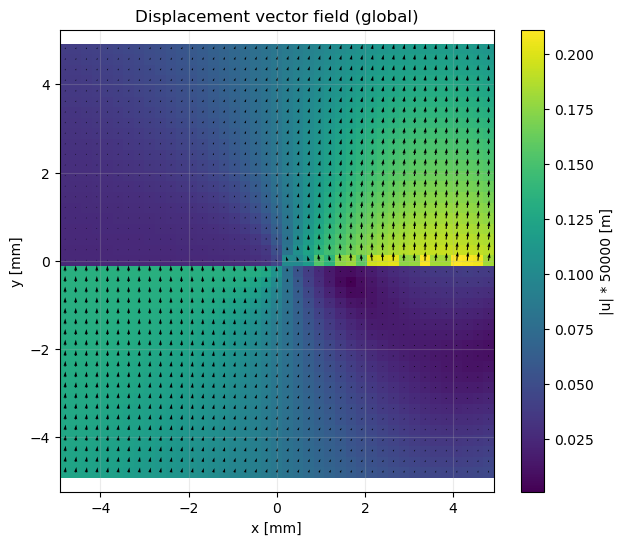

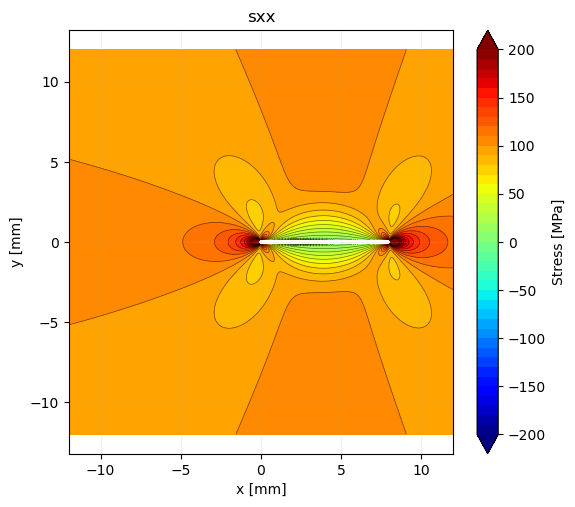

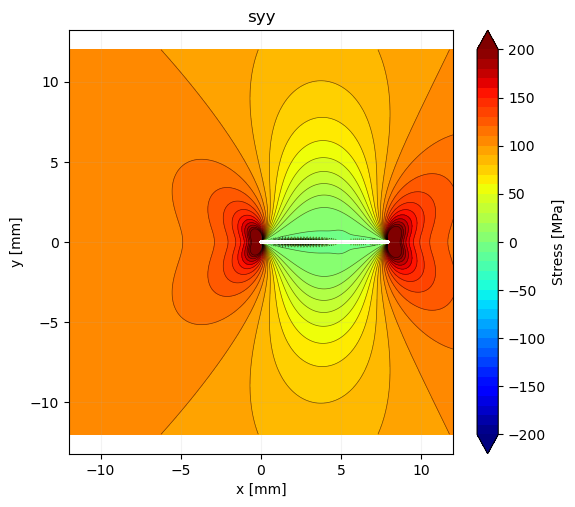

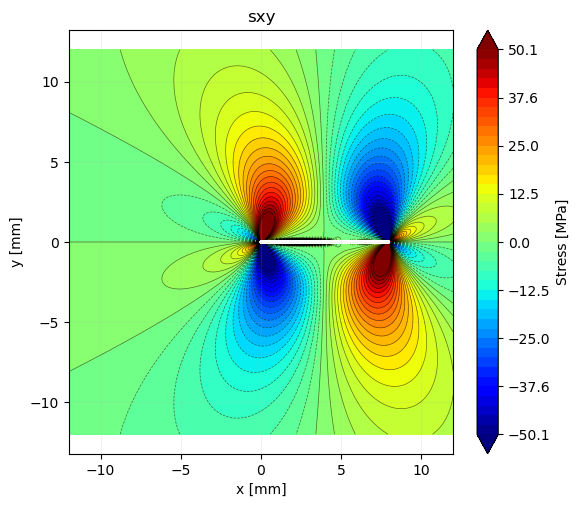

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1


In [14]:

from preamble import *
enable_autoreload()
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1")
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 junction
    [1,   5.0*mm,  0*mm], # v1 upper-right
    [2,   8.0*mm, 0.0*mm], # v2 lower-right
    # [3,   5.0*mm, -4.0*mm], # v3 upper-left
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
    [1, 2],
    # [1, 3],
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Deformed crack network
plotter.plot_deformed_network(scale=5e1, n_pts_per_edge=800, 
                              show_faces=True, cod_smooth_window=5)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)




In [ ]:

# -------------------------
# Kink projected closure check (degree-2)
# -------------------------
import numpy as np

# -------------------------
# Build v_inc locally (vertex -> incident (pid, start/end))
# -------------------------
e2p   = sol["parametrized_edge_to_polyline"]
polys = sol["parametrized_polylines"]
solps = sol["polyline_solutions"]

v_inc = {}
for ei, pid in e2p.items():
    pid = int(pid)
    meta = polys[pid]
    v_start = int(meta.get("v_start", meta["path_vertex_ids"][0]))
    v_end   = int(meta.get("v_end",   meta["path_vertex_ids"][-1]))
    v_inc.setdefault(v_start, []).append((pid, "start"))
    v_inc.setdefault(v_end,   []).append((pid, "end"))

def outgoing_tangent(pid, which):
    s = solps[pid]
    t = np.asarray(s.get("t_mid", s.get("t_col")), float)
    tt = (+t[0]) if which == "start" else (-t[-1])
    nrm = np.linalg.norm(tt)
    return tt / nrm if nrm > 0 else np.array([1.0, 0.0])

def B_of_branch(pid):
    s = solps[pid]
    bI  = np.asarray(s["bI"],  float)
    bII = np.asarray(s["bII"], float)
    ds  = np.asarray(s["ds"],  float)
    t   = np.asarray(s.get("t_mid", s.get("t_col")), float)
    n   = np.asarray(s.get("n_mid", s.get("n_col")), float)
    B = np.zeros(2)
    for k in range(len(ds)):
        B += (bII[k]*t[k] + bI[k]*n[k]) * ds[k]
    return B

# -------------------------
# Kink projected closure check (degree-2)
# -------------------------
vk = 1  # kink vertex id

items = v_inc.get(vk, [])
print("\n--- Kink projected closure check ---")
print("vk =", vk, "incident items =", items)

if len(items) != 2:
    print("ERROR: expected exactly 2 incident branches at kink.")
else:
    (pid0, w0), (pid1, w1) = items[0], items[1]
    t0 = outgoing_tangent(pid0, w0)
    t1 = outgoing_tangent(pid1, w1)

    b = t0 + t1
    nb = np.linalg.norm(b)
    if nb <= 0:
        print("ERROR: bisector undefined (t0 ~ -t1).")
    else:
        b /= nb
        n_bis = np.array([-b[1], b[0]])  # bisector normal (CCW)

        B0 = B_of_branch(pid0)
        B1 = B_of_branch(pid1)
        Bsum = B0 + B1

        print(f"pid0={pid0} ({w0})  B0={B0}")
        print(f"pid1={pid1} ({w1})  B1={B1}")
        print("Bsum =", Bsum, " |Bsum| =", float(np.linalg.norm(Bsum)))
        print("n_bis =", n_bis)
        print("n_bis · Bsum =", float(n_bis @ Bsum))



--- Kink projected closure check ---
vk = 1 incident items = [(0, 'start'), (1, 'start')]
pid0=0 (start)  B0=[ 2.00121869e-06 -6.37909680e-06]
pid1=1 (start)  B1=[-2.19283850e-06  7.01197404e-06]
Bsum = [-1.91619809e-07  6.32877236e-07]  |Bsum| = 6.612501395256865e-07
n_bis = [-0.95709203 -0.28978415]
n_bis · Bsum = -5.01602323452156e-20


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Loaded network: 7 vertices, 5 edges
  Node IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


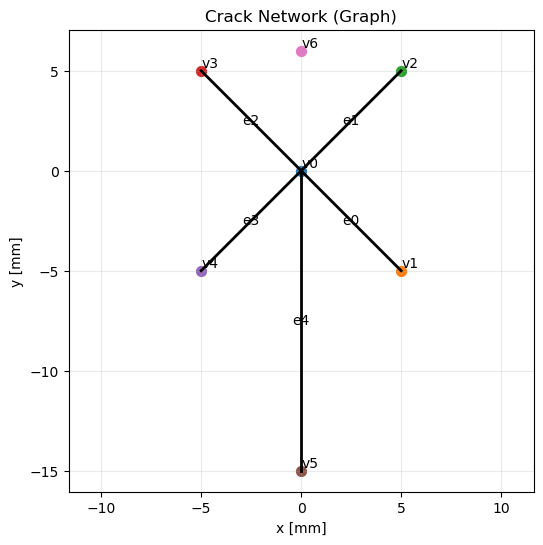

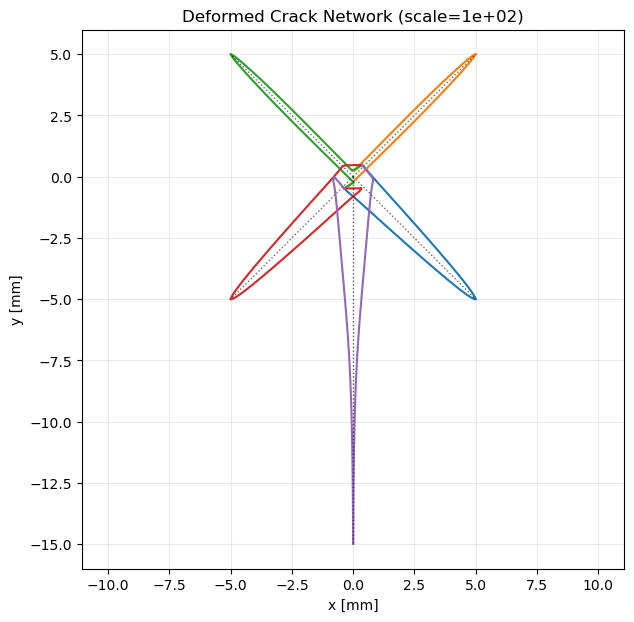

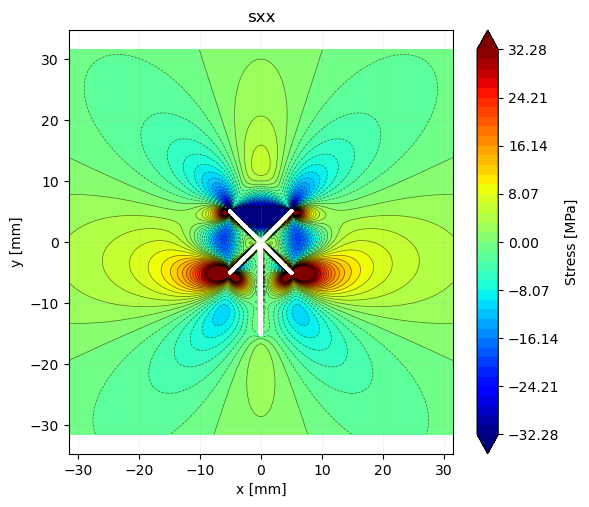

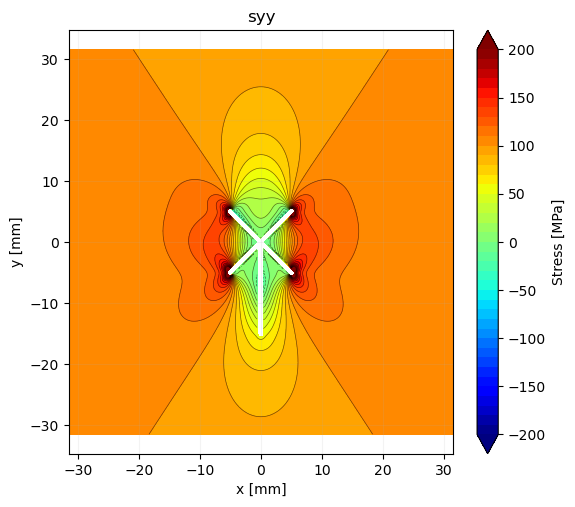

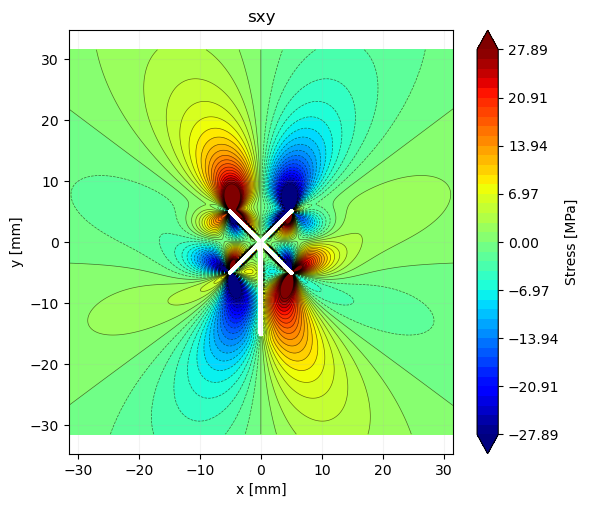

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half


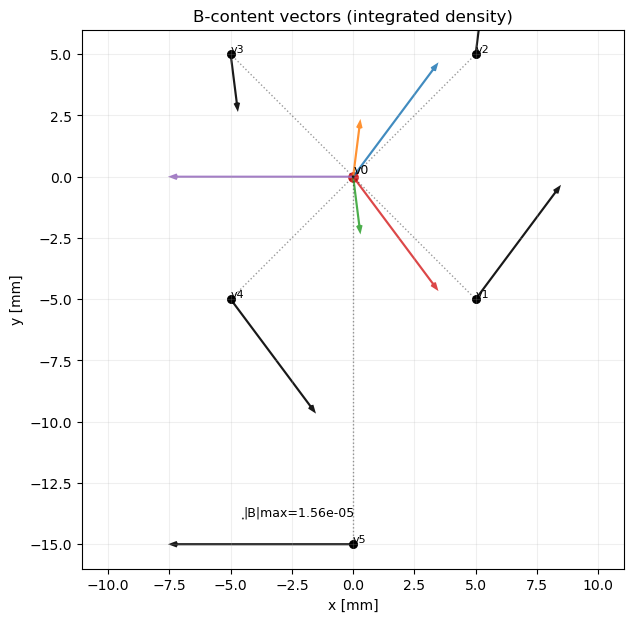

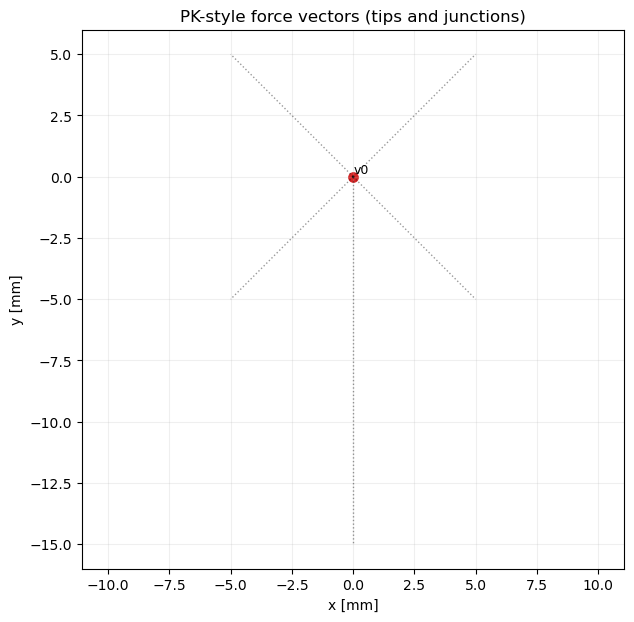

In [ ]:

from preamble import *
enable_autoreload()

mm = 1e-3
vertices = np.array([
    [0,  0.0*mm,  0.0*mm],   # junction
    [1,  5.0*mm, - 5.0*mm],   # left tip
    [2, 5.0*mm,  5.0*mm],   # upper tip
    [3, -5.0*mm, 5.0*mm],
    [4, -5.0*mm, -5.0*mm], 
    [5, 0.0*mm, -15.0*mm], 
    [6, 0.0*mm, 6.0*mm],   # lower tip
    # [7, -4.0*mm, 0.0*mm],   # upper tip
    # [8, -12.0*mm, 0.0*mm]
    ], dtype=float)

# Each edge: [start_node, end_node]
connectivity = [
    [0, 1],  # Edge 0: from node 0 to node 1
    [0, 2],  # Edge 1: from node 0 to node 2
    [0, 3],  # Edge 2: from node 0 to node 3
    [0, 4],  # Edge 3: from node 0 to node 4
    [0, 5],  # Edge 4: from node 0 to node 5
    # [0, 6],  # Edge 5: from node 0 to node 6
    # [7, 8],  # Edge 6: from node 7 to node 8
    ]

generator = CrackNetworkGenerator(domain_size=(25e-3, 25e-3))
generator.load_from_arrays(vertices, connectivity)

net = CrackNetworkV4.from_vertices_connectivity(vertices=vertices, connectivity=connectivity, Nv_max=8, validate=True)
material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)
sol  = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
)

res = DCEResultsNetworkV4(calc, sol)

out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half")
out_dir.mkdir(parents=True, exist_ok=True)

plotter = DCEPlotterV4(res, out_dir=out_dir)

plotter.plot_network_graph()
plotter.plot_deformed_network(scale=1e2, n_pts_per_edge=2000, show_faces=True, cod_smooth_window=5)

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)

from utils_half.plotter_PK import DCEPlotterPK, VecPlotStyle

pkplt = DCEPlotterPK(res, out_dir=out_dir)

# (2) B-content vectors (kinematic integrated density; your “B” diagnostic)
from utils_half.plotter_PK import DCEPlotterPK, VecPlotStyle

pkplt = DCEPlotterPK(res, out_dir=out_dir)

fig = pkplt.plot_b_content_vectors(
    style=VecPlotStyle(max_len_factor=0.18),  # optional
    user_scale=2e-3,                           # <-- single knob for arrow size
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

# (3) PK-style forces (stress-based; requires stress evaluator)
fig = pkplt.plot_pk_force_vectors(
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1.0,
    units="mm",
    exclude_self=True,     # needs res.stress_field_global_excluding(...)
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)




In [ ]:

print("\n=== JUNCTION CONSTRAINT DIAGNOSTICS (HALF CRACK, Option A) ===")

# ---- convenience handles from solution dict ----
e2p    = sol["parametrized_edge_to_polyline"]
polys  = sol["parametrized_polylines"]
solps  = sol["polyline_solutions"]

# ---- compute vertex degrees from edges (no VertexV4.degree needed) ----
deg = {int(v.id): 0 for v in calc.network.vertices}
for e in calc.network.edges:
    deg[int(e.v0)] = deg.get(int(e.v0), 0) + 1
    deg[int(e.v1)] = deg.get(int(e.v1), 0) + 1

# ---- build vertex -> incident (pid, which_end) map ----
v_inc = {}
for ei, pid in e2p.items():
    pid = int(pid)
    pmeta = polys[pid]
    v0 = int(pmeta.get("v_start", pmeta["path_vertex_ids"][0]))
    v1 = int(pmeta.get("v_end",   pmeta["path_vertex_ids"][-1]))
    v_inc.setdefault(v0, []).append((pid, "start"))
    v_inc.setdefault(v1, []).append((pid, "end"))

# ---- helpers ----
def outgoing_tangent(pid, which):
    s = solps[pid]
    t = np.asarray(s.get("t_mid", s.get("t_col")), float)
    if which == "start":
        return +t[0]
    else:
        return -t[-1]

def B_of_branch(pid):
    s = solps[pid]
    bI  = np.asarray(s["bI"],  float)
    bII = np.asarray(s["bII"], float)
    ds  = np.asarray(s["ds"],  float)
    t   = np.asarray(s.get("t_mid", s.get("t_col")), float)
    n   = np.asarray(s.get("n_mid", s.get("n_col")), float)

    B = np.zeros(2)
    for k in range(len(ds)):
        B += (bII[k]*t[k] + bI[k]*n[k]) * ds[k]
    return B

def J_at_vertex(pid, which):
    s = solps[pid]
    bI  = np.asarray(s["bI"],  float)
    bII = np.asarray(s["bII"], float)
    ds  = np.asarray(s["ds"],  float)
    t   = np.asarray(s.get("t_mid", s.get("t_col")), float)
    n   = np.asarray(s.get("n_mid", s.get("n_col")), float)

    J0 = np.asarray(s.get("J0", [0.0, 0.0]), float)
    J = J0.copy()

    if which == "end":
        for k in range(len(ds)):
            J -= (bII[k]*t[k] + bI[k]*n[k]) * ds[k]
    return J

# ---- diagnostics per junction ----
for v, items in v_inc.items():
    dv = deg.get(int(v), 0)
    if dv < 2:
        continue

    print(f"\n--- Vertex v={v} (degree={dv}) ---")
    print("Incident branches (pid, end):", items)

    # J continuity
    Js = []
    for (pid, which) in items:
        Jv = J_at_vertex(pid, which)
        Js.append(Jv)
        print(f"  pid {pid:2d}  J(v) = {Jv}")

    J_ref = Js[0]
    for j, Jv in enumerate(Js[1:], start=1):
        print(f"  |J[{j}] - J[0]| = {np.linalg.norm(Jv - J_ref):.3e}")

    # Burgers content
    Bs = []
    for (pid, _) in items:
        Bj = B_of_branch(pid)
        Bs.append(Bj)
        print(f"  pid {pid:2d}  B = {Bj}")

    Bsum = np.sum(Bs, axis=0)
    print("  Sum B =", Bsum, " |norm| =", np.linalg.norm(Bsum))

    # Option B projected neutrality check (only for dv >= 3)
    if dv >= 3:
        g = np.zeros(2)
        for (pid, which) in items:
            g += outgoing_tangent(pid, which)

        ng = np.linalg.norm(g)
        if ng > 0:
            g /= ng
            proj = np.array([-g[1], g[0]])
            r = float(proj @ Bsum)
            print("  Projection direction p =", proj)
            print("  p · Sum B =", r)
        else:
            print("  WARNING: could not form projection direction (ng=0)")
            
            print("\n--- Tip jump check (Option A sanity) ---")
for pid, meta in enumerate(sol["parametrized_polylines"]):
    vids = meta["path_vertex_ids"]
    v_start, v_end = int(vids[0]), int(vids[-1])
    # start is junction end, end is tip end in your convention
    J_start = J_at_vertex(pid, "start")
    J_end   = J_at_vertex(pid, "end")
    print(f"pid {pid}: v_start={v_start} (deg={deg[v_start]}), v_end={v_end} (deg={deg[v_end]})")
    print(f"   J(start)={J_start},  J(end/tip)={J_end}")


print("\n=== END JUNCTION DIAGNOSTICS ===")


# common J at the junction from your diagnostic (or recompute from solps)
Jv = np.array([-1.14324090e-06, -1.02223602e-05])  # example

# outgoing unit tangents at junction (use your diagnostic helper)
def unit(v):
    n = np.linalg.norm(v)
    return v/n if n>0 else v

for (pid, which) in [(0,"start"), (1,"start"), (2,"start")]:
    t = outgoing_tangent(pid, which)          # from your diagnostic snippet
    t = unit(t)
    n = np.array([-t[1], t[0]])               # CCW normal
    COD = float(Jv @ n)
    CSD = float(Jv @ t)
    print(f"pid {pid}: COD(v0)={COD:.3e}  CSD(v0)={CSD:.3e}")
    
import numpy as np

def tip_jump_from_reconstruction(res, edge_index):
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )
    ex = np.asarray(extra["ex"], float)
    ey = np.asarray(extra["ey"], float)

    COD_tip = float(COD[-1])
    CSD_tip = float(CSD[-1])

    J_tip = ex * CSD_tip + ey * COD_tip
    return COD_tip, CSD_tip, J_tip

for ei in [0, 1, 2]:
    COD_tip, CSD_tip, J_tip = tip_jump_from_reconstruction(res, ei)
    print(f"edge {ei}: COD_tip={COD_tip:+.3e}  CSD_tip={CSD_tip:+.3e}  J_tip={J_tip}")


=== JUNCTION CONSTRAINT DIAGNOSTICS (HALF CRACK, Option A) ===

--- Vertex v=0 (degree=4) ---
Incident branches (pid, end): [(0, 'start'), (1, 'start'), (2, 'start'), (3, 'start')]
  pid  0  J(v) = [ 1.19603854e-06 -1.17613249e-05]
  pid  1  J(v) = [ 1.19603854e-06 -1.17613249e-05]
  pid  2  J(v) = [ 1.19603854e-06 -1.17613249e-05]
  pid  3  J(v) = [ 1.19603854e-06 -1.17613249e-05]
  |J[1] - J[0]| = 0.000e+00
  |J[2] - J[0]| = 0.000e+00
  |J[3] - J[0]| = 0.000e+00
  pid  0  B = [ 1.19603854e-06 -1.17613249e-05]
  pid  1  B = [1.56012333e-06 4.91057122e-06]
  pid  2  B = [5.54243781e-06 8.25095461e-06]
  pid  3  B = [-8.29859969e-06 -1.40020096e-06]
  Sum B = [-4.91279109e-20  1.40607469e-19]  |norm| = 1.4894298251567528e-19
  Projection direction p = [0.92387953 0.38268343]
  p · Sum B = 8.419877553348864e-21
pid 0: v_start=0 (deg=4), v_end=1 (deg=1)
   J(start)=[ 1.19603854e-06 -1.17613249e-05],  J(end/tip)=[1.41083925e-20 1.27054942e-21]
pid 1: v_start=0 (deg=4), v_end=2 (deg=1)
   

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


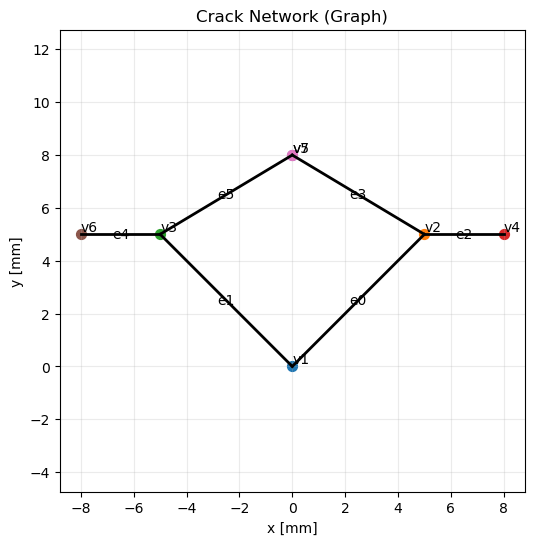

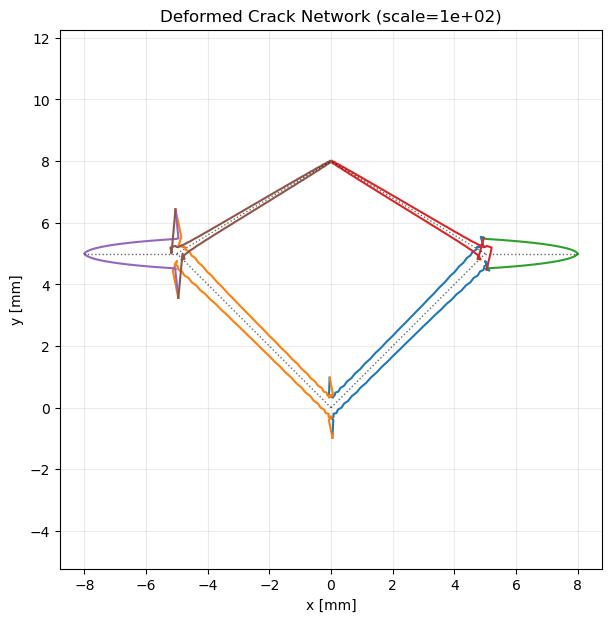

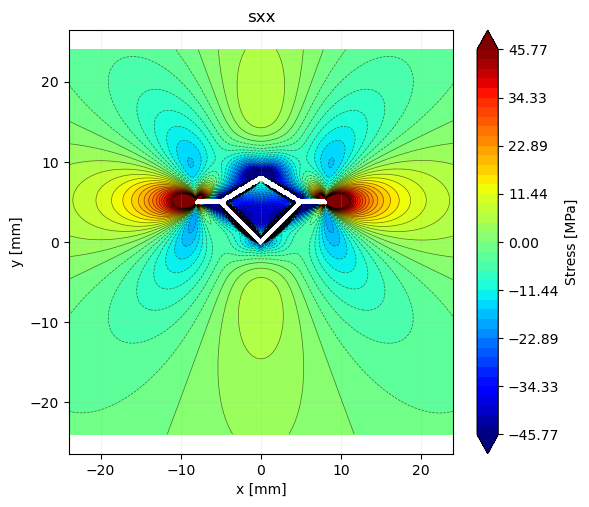

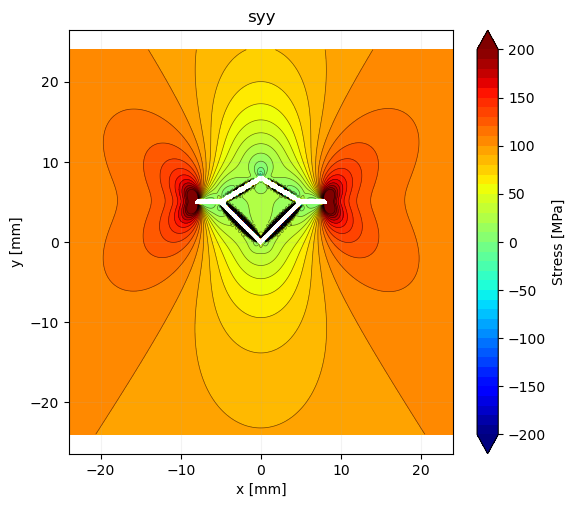

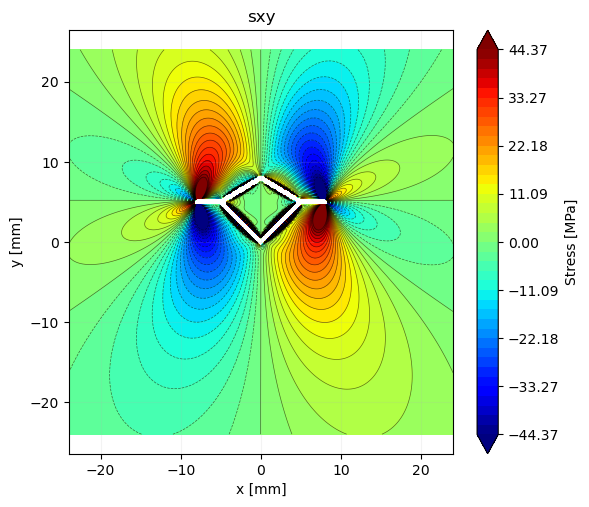

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half


In [ ]:

from preamble import *
enable_autoreload()

mm = 1e-3
vertices = np.array([
    [1,  0.0*mm,  0.0*mm],   
    [2,  5.0*mm,  5.0*mm],   
    [3, -5.0*mm,  5.0*mm],   
    [4, 8.0*mm, 5.0*mm],
    [5, 0.0*mm, 8.0*mm],
    [6, -8.0*mm, 5.0*mm],
    [7, 0.0*mm, 8.0*mm],  
], dtype=float)

connectivity = np.array([[1,2],[1,3],[2,4],[2,5],[3,6],[3,7]], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(vertices=vertices, connectivity=connectivity, Nv_max=4, validate=True)
material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)
sol  = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
)

res = DCEResultsNetworkV4(calc, sol)

out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half")
out_dir.mkdir(parents=True, exist_ok=True)

plotter = DCEPlotterV4(res, out_dir=out_dir)

plotter.plot_network_graph()
plotter.plot_deformed_network(scale=1e2, n_pts_per_edge=2000, show_faces=True, cod_smooth_window=5)

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


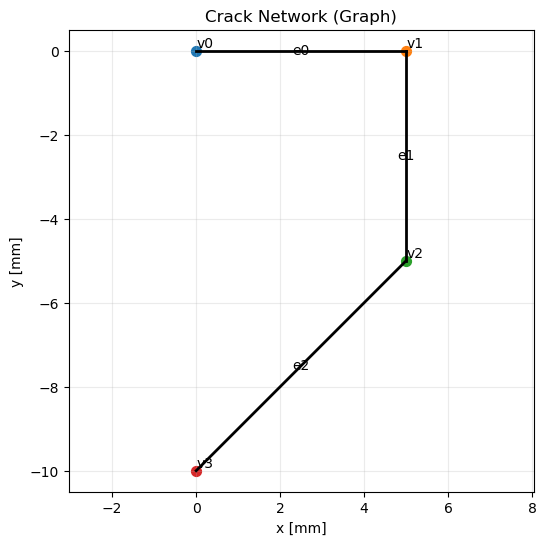

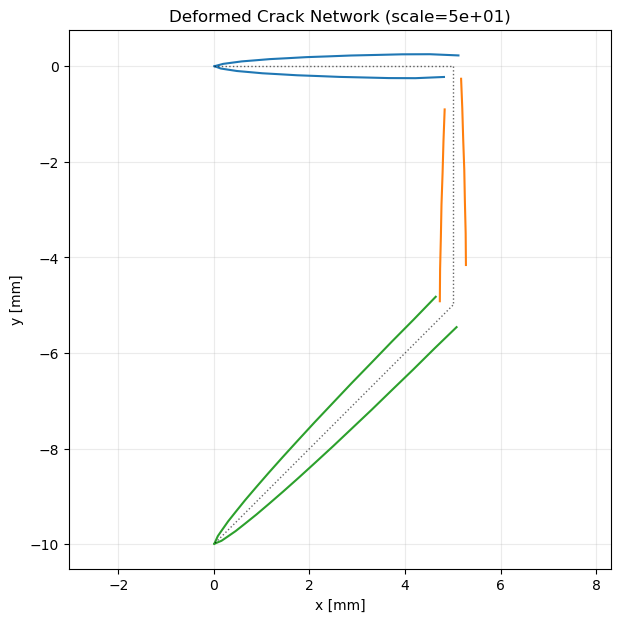

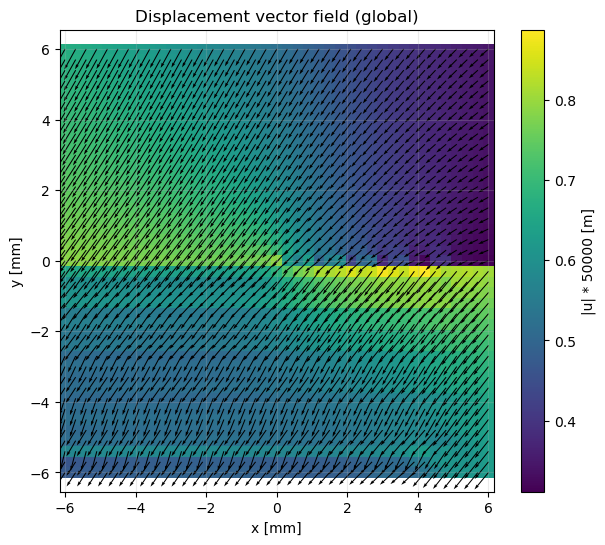

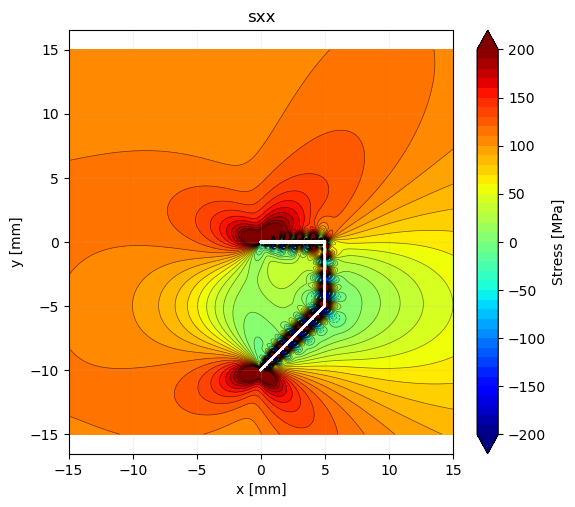

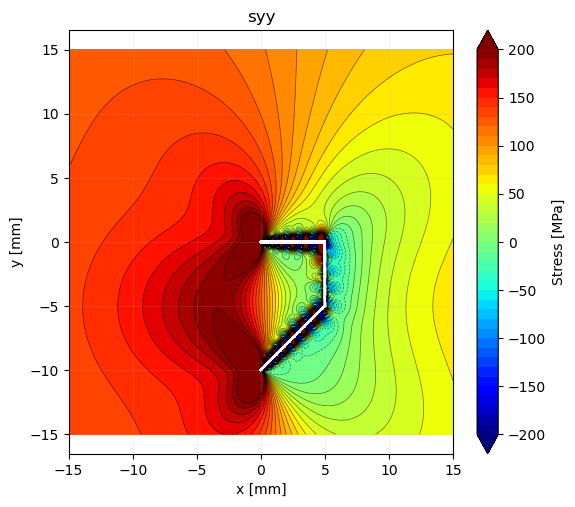

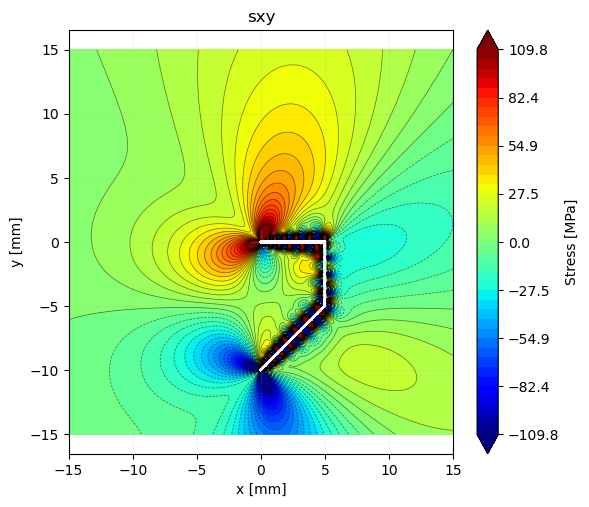

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1


In [ ]:

from preamble import *
enable_autoreload()
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1")
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 junction
    [1,   5.0*mm,  0*mm], # v1 upper-right
    [2,   5.0*mm, -5.0*mm], # v2 lower-right
    [3,  0*mm,  -10.0*mm], # v3 extended lower-right
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
    [1, 2],
    [2, 3]
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

# -------------------------
# Solve
# -------------------------
sol = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,   # OK to keep; ignored by the delegated single-crack solve
    n_int=96,
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Deformed crack network
plotter.plot_deformed_network(scale=5e1, n_pts_per_edge=800, 
                              show_faces=True, cod_smooth_window=5)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Generated network: 15 vertices, 6 edges

CRACK NETWORK STATISTICS
Vertices:       15
  Tips:         12
  Junctions:    0
  Internal:     3
Edges:          6
Edge lengths:
  Mean:         13.738 mm
  Std dev:      3.499 mm
  Min:          9.505 mm
  Max:          18.453 mm
Total length:   82.428 mm

EXPORTED ARRAYS

vertices =
[[0.03745401 0.09507143]
 [0.07319939 0.05986585]
 [0.01560186 0.01559945]
 [0.00580836 0.08661761]
 [0.0601115  0.07080726]
 [0.00205845 0.09699099]
 [0.08324426 0.02123391]
 [0.0181825  0.01834045]
 [0.03042422 0.05247564]
 [0.0431945  0.02912291]
 [0.06118529 0.01394939]
 [0.02921446 0.03663618]
 [0.045607   0.0785176 ]
 [0.01996738 0.05142344]
 [0.05924146 0.00464504]]

connectivity =
[[ 0 12]
 [ 1  4]
 [ 3  5]
 [ 8 13]
 [ 9 11]
 [10 14]]

vertex_types =
['tip', 'tip', 'internal', 'tip', 'tip', 'tip', 'internal', 'internal', 'tip', 'tip', 'tip', 'tip', 'tip', 'tip', 'tip

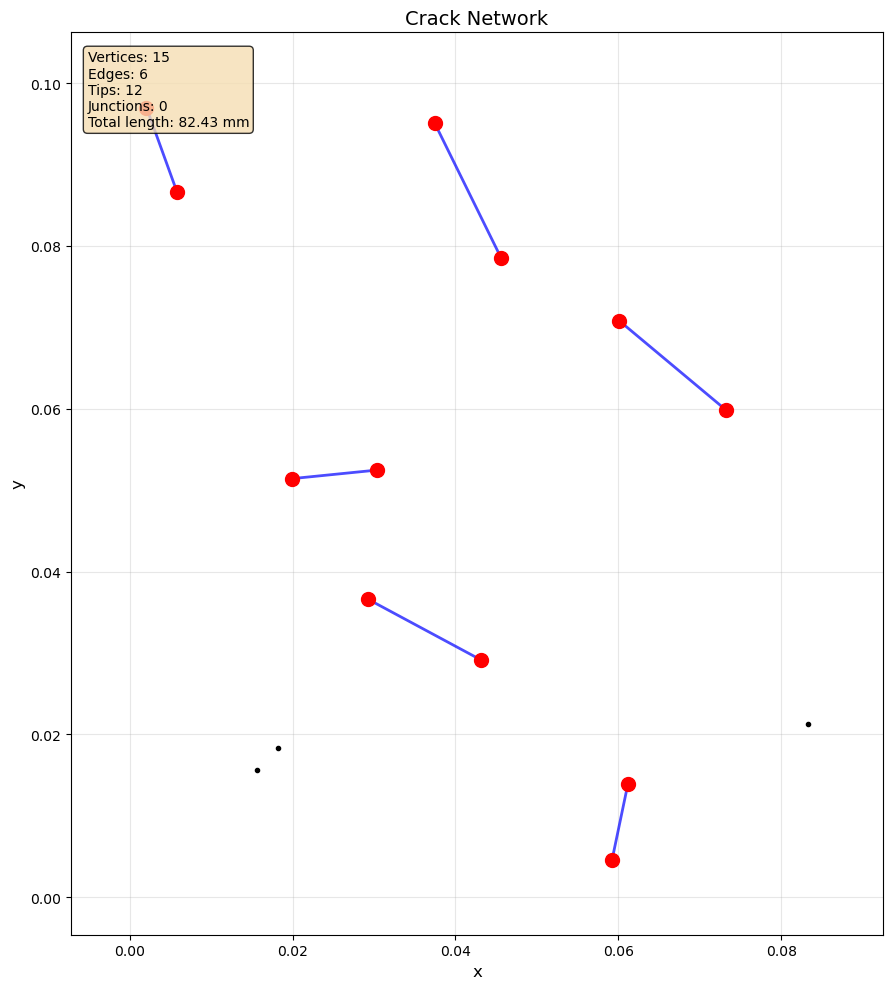

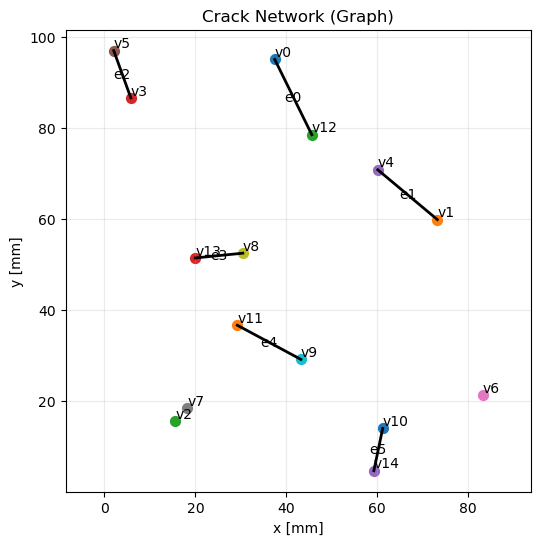

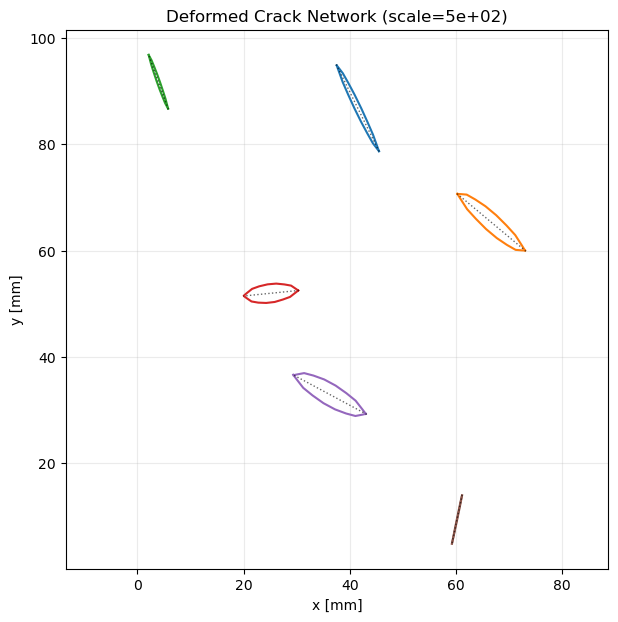

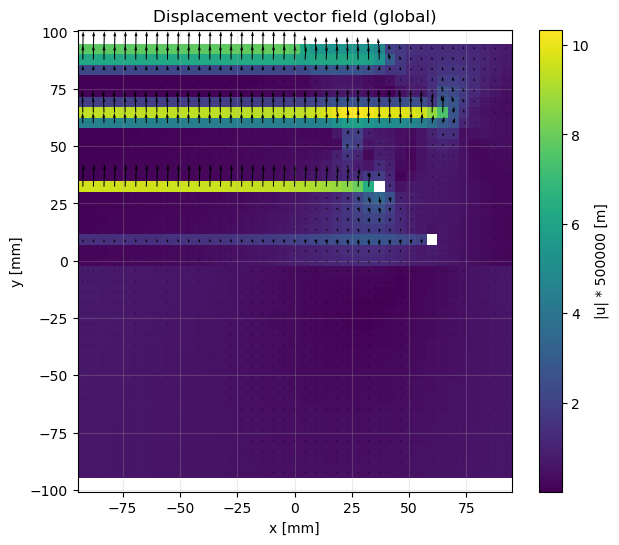

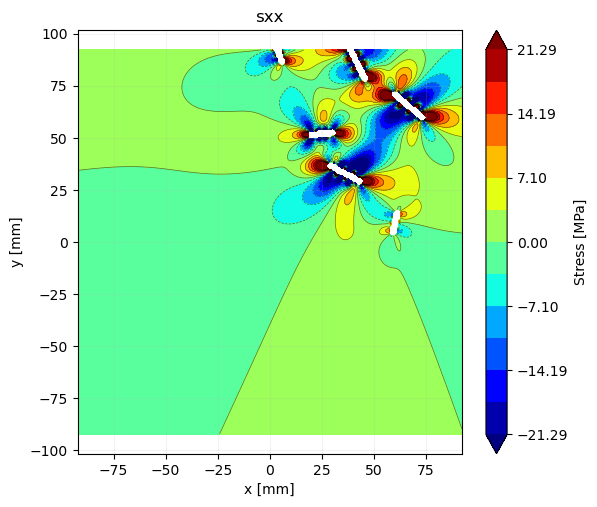

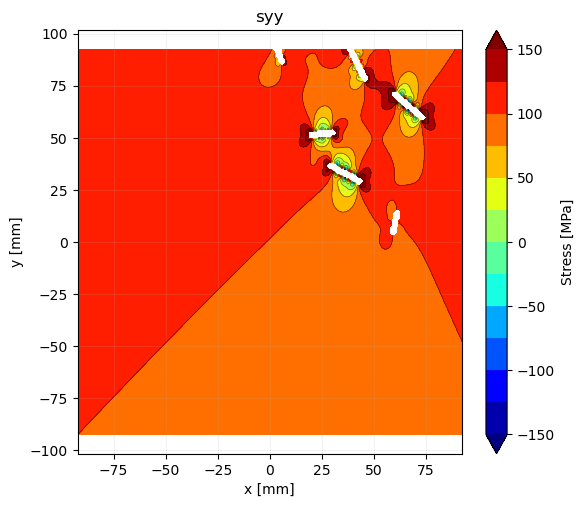

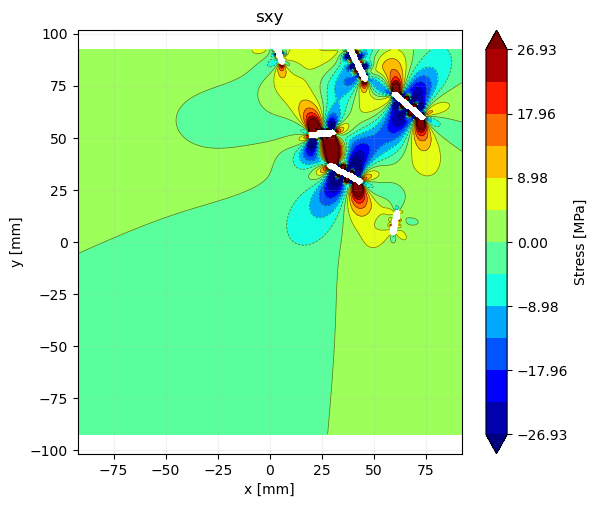

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-2


In [6]:

from preamble import *
enable_autoreload()


mm = 1e-3
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-2")
out_dir.mkdir(parents=True, exist_ok=True)

generator = CrackNetworkGenerator(
    domain_size=(100*mm, 100*mm),
    seed=42,
)


# Generate network
generator.generate_network(
    n_junctions=0,           # Number of junction vertices
    n_tips=15,                # Number of tip vertices
    edge_length_mean=40*mm,   # Mean edge length
    edge_length_std=5*mm,    # Std dev of edge length
    max_junction_order=3,    # Max junction degree (3-4 typical)
    spatial_distribution='uniform',  # 'uniform', 'clustered', 'grid'
    connection_strategy='nearest_neighbor',  # 'nearest_neighbor', 'delaunay', 'random'
    min_edge_length=5*mm,
    max_edge_length=20*mm
)

# Print statistics
generator.print_statistics()

# Visualize
fig, ax = generator.visualize(
    figsize=(12, 10),
    show_labels=False,
    show_edge_labels=False,
    node_size=10,
    edge_color='blue',
    edge_width=2.0
)
# plt.show()

# Export to your format
vertices, connectivity, vertex_types = generator.to_arrays()

print("\n" + "="*60)
print("EXPORTED ARRAYS")
print("="*60)
print("\nvertices =")
print(vertices)
print("\nconnectivity =")
print(connectivity)
print("\nvertex_types =")
print(vertex_types)

# Use with your CrackNetworkV4
net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)
material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material=material, network=net, applied=applied)

sol = calc.solve(
    ne_half=5,                   # start here
    representation="cheb_quad",   # keep cheb_quad and cheb_spectral available
    node_distribution="tip_dense"
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# -------------------------
# Network-level plots
# -------------------------
plotter.plot_network_graph()
plotter.plot_deformed_network(scale=5e2, n_pts_per_edge=1000)  # scale in plot title

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e5,       # <--- magnify displacements for visibility
)

# Stress fields (global) with bands/contours
opts = StressPlotOptsV4(
    extent_factor=2,
    n_grid=251,
    add_remote=True,
    vmax_factor=1.5,     # cap at 10x remote component (MPa basis)
    cmap="jet",
    n_bands=12,
    label_contours=False,
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Generated network: 20 vertices, 15 edges

CRACK NETWORK STATISTICS
Vertices:       20
  Tips:         12
  Junctions:    2
  Internal:     6
Edges:          15
Edge lengths:
  Mean:         2.875 mm
  Std dev:      1.704 mm
  Min:          0.669 mm
  Max:          6.447 mm
Total length:   43.126 mm


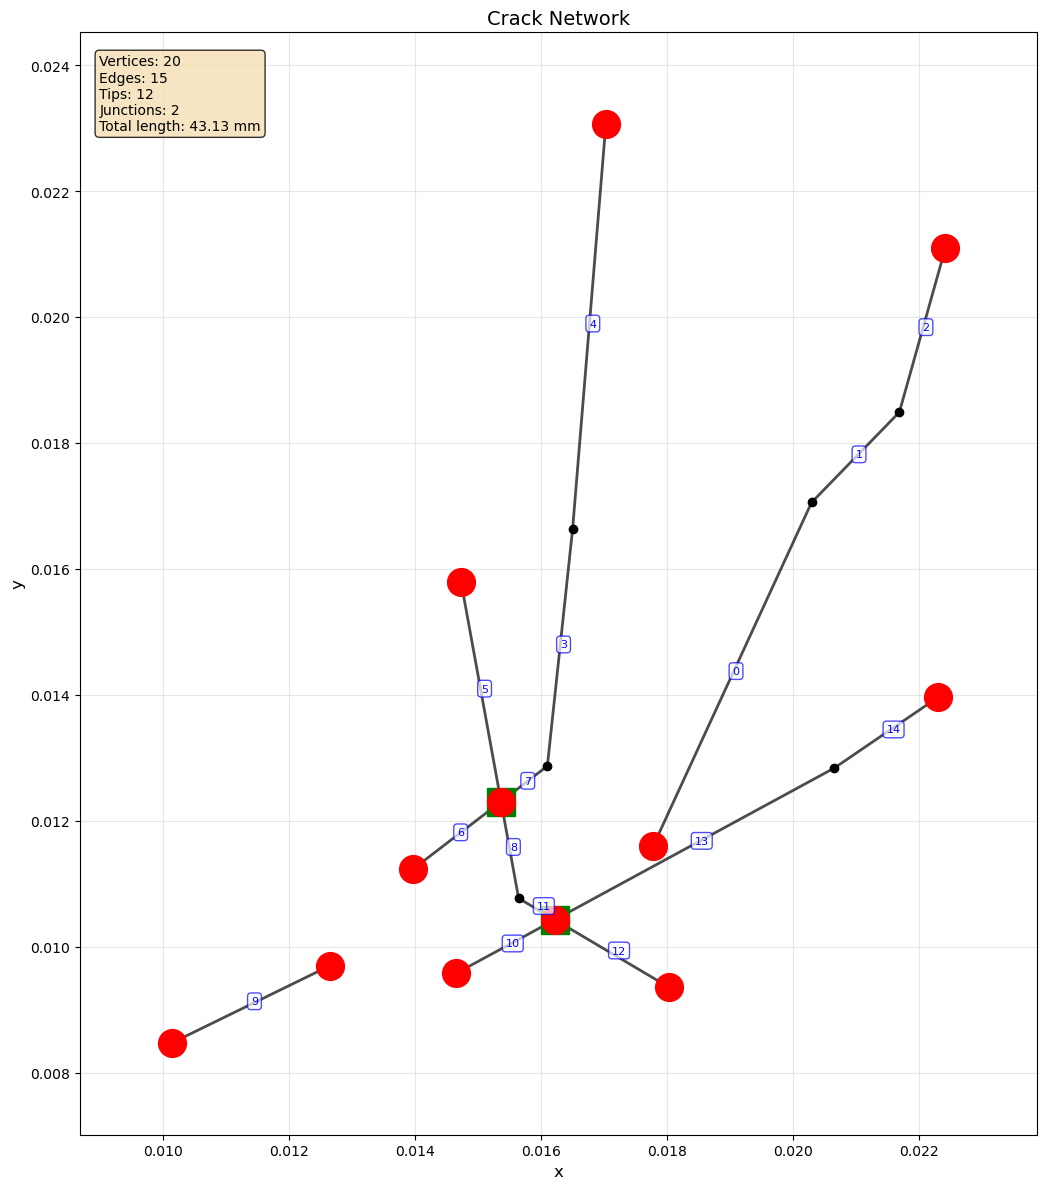

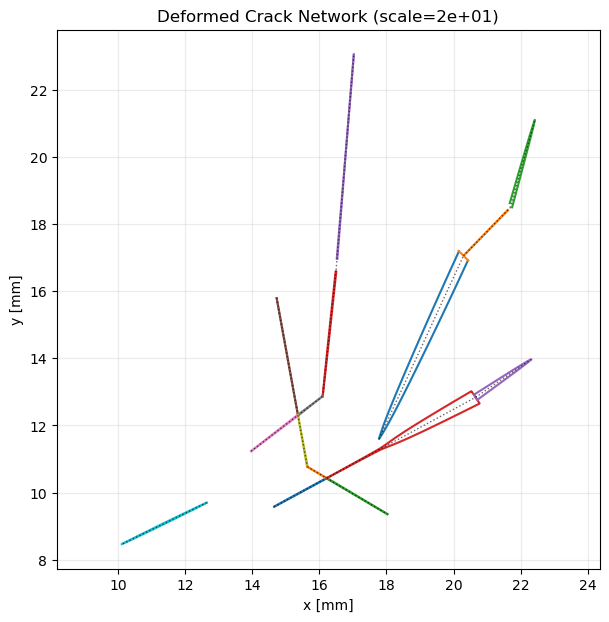

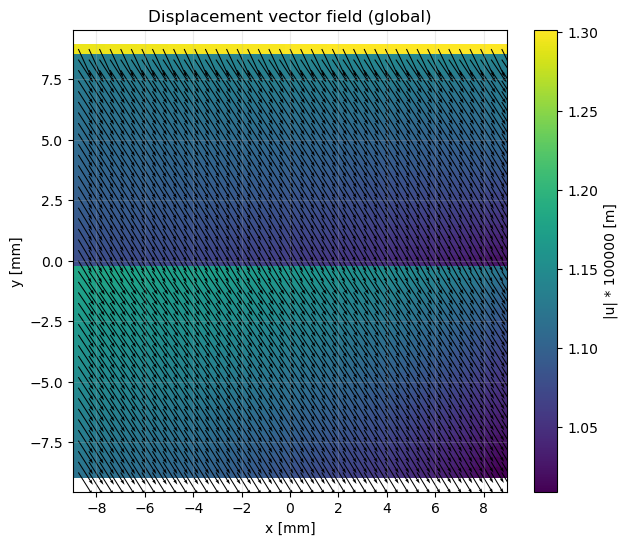

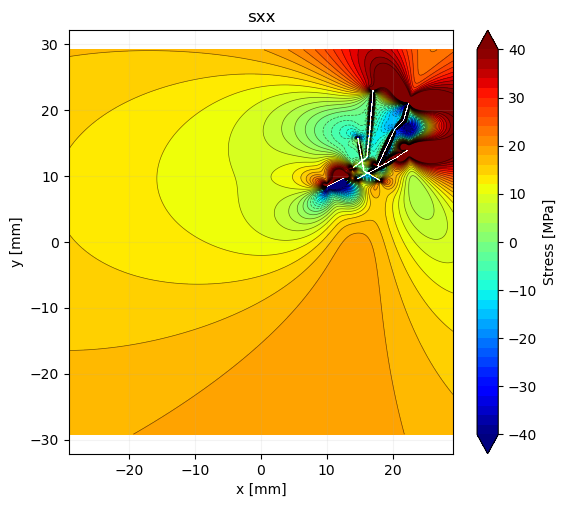

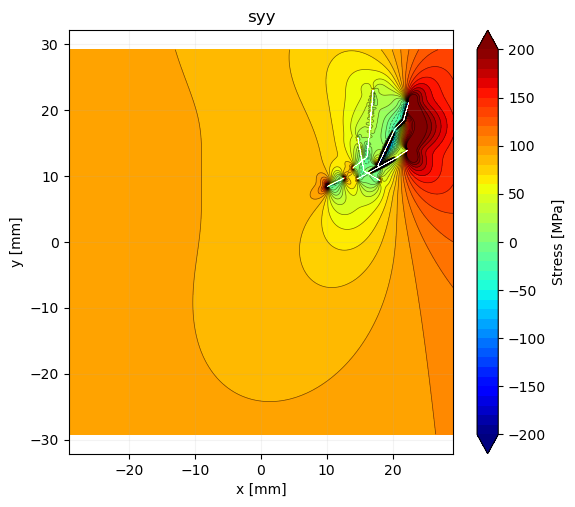

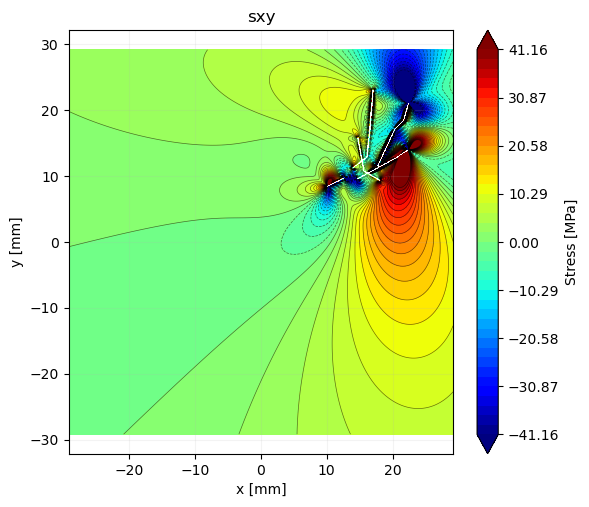

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\parametrized_cracks_2seg


In [ ]:

from preamble import *
enable_autoreload()


# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\parametrized_cracks_2seg")
out_dir.mkdir(parents=True, exist_ok=True)

mm=1e-3
# Generate exactly 3 non-intersecting meandering cracks, each with 3 edges
generator = CrackNetworkGenerator(
    domain_size=(25*mm, 25*mm),
    seed=4  # Change seed for different patterns
)

generator.generate_network(
    n_junctions=4,
    n_tips=10,
    
    # Edge properties for meandering
    edge_length_mean=5*mm,
    edge_length_std=2*mm,
    min_edge_length=2*mm,
    max_edge_length=10*mm,
    
    # Exactly 3 cracks, each with 3 segments
    n_crack_paths=5,
    segments_per_path_mean=4,
    segments_per_path_std=2,  # Some variation in segments per path
    
    # Small random angles for meandering
    path_angle_change_mean_deg=0.0,     # No systematic turn
    path_angle_change_std_deg=30.0,     # Small random angles (±30°)
    
    # Non-intersecting
    allow_intersections=True,
    min_edge_distance=1.0*mm,  # Keep cracks separated
    
    spatial_distribution='clustered'
)


# Print statistics
generator.print_statistics()

# Visualize with path coloring to see the 3 separate cracks
fig2, ax2 = generator.visualize(
    figsize=(12, 12),
    node_size=20,
    edge_width=2.0,
    show_labels=True,
    show_edge_labels=True,
    edge_color='black'
)
plt.show()
vertices, connectivity, vertex_types = generator.to_arrays()

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=20e6, sigma_yy=100e6, sigma_xy=0e6)

calc = DCENetworkStaticV4(material, net, applied)

# -------------------------
# Parametrized crack solve (no COD=0 enforced at the interior degree-2 vertex)
# -------------------------
sol = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,   # OK to keep; ignored by the delegated single-crack solve
    n_int=96,
    crack_mode="half"
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Deformed crack network
plotter.plot_deformed_network(scale=2e1, n_pts_per_edge=500, 
                              n_theta=10000,show_faces=True)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=1e5,
    mask_cracks=True,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=4,
    n_grid=1000,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
    mask_width_factor=1e-2
)

plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)





The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


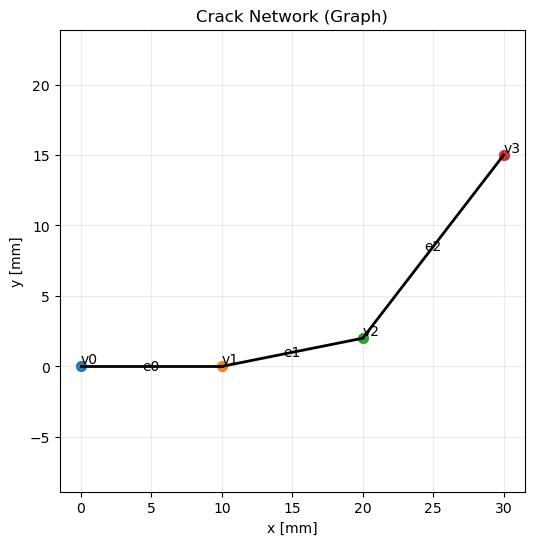

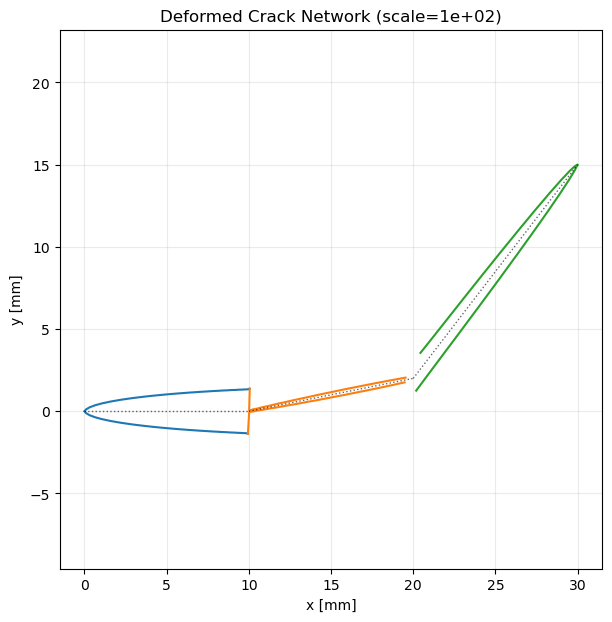

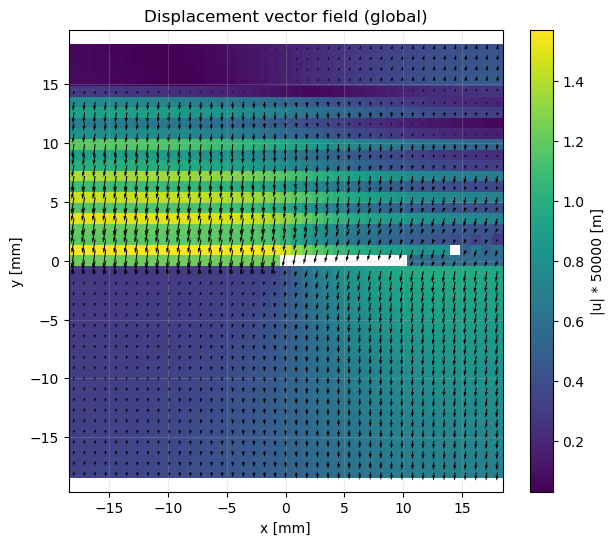

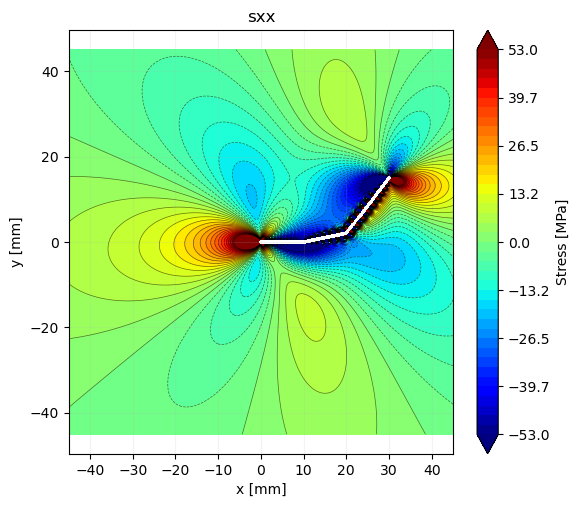

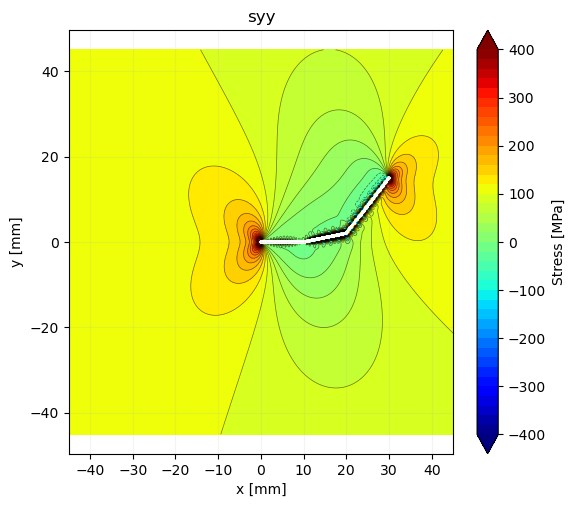

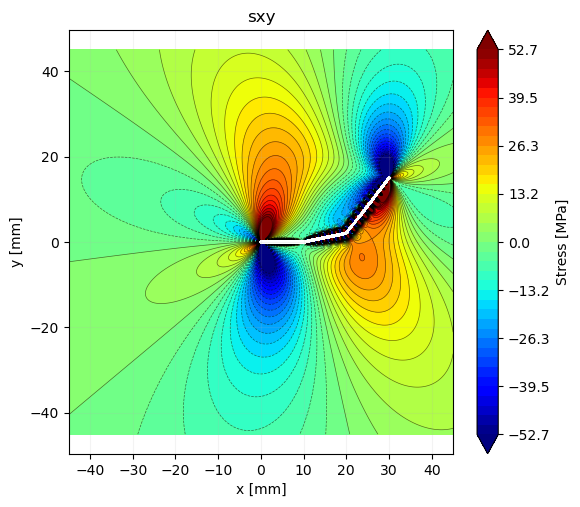

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\kinks_2seg


In [ ]:

from preamble import *
enable_autoreload()


# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\kinks_2seg")
out_dir.mkdir(parents=True, exist_ok=True)

mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 (left end)
    [1,  10.0*mm,  0.0*mm],   # v1 (kink / interior vertex, degree 2)
    [2,  20.0*mm,  2*mm],   # v2 (right end)
    [3,  30.0*mm,  15*mm],   # v3 (extra vertex, not used)
], dtype=float)

connectivity = np.array([
    [0, 1],   # e0
    [1, 2],   # e1
    [2, 3]
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=100e6, sigma_xy=0e6)

calc = DCENetworkStaticV4(material, net, applied)
sol = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,   # OK to keep; ignored by the delegated single-crack solve
    n_int=96,
    crack_mode="half"
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Deformed crack network
plotter.plot_deformed_network(scale=1e2, n_pts_per_edge=800, 
                              show_faces=True, cod_smooth_window=5)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=True,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=True,
    mask_width_factor=1e-4,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=4
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


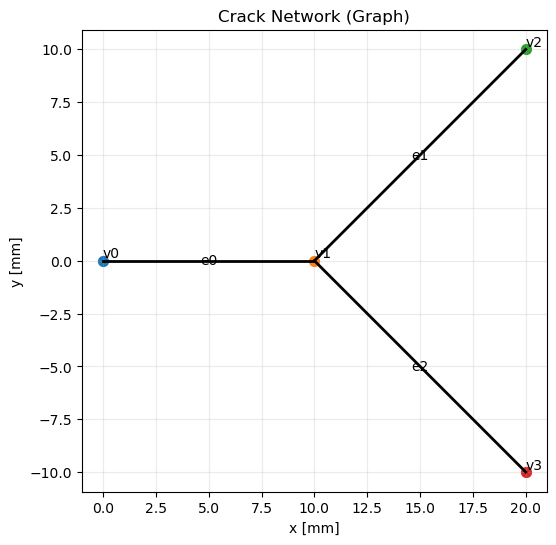

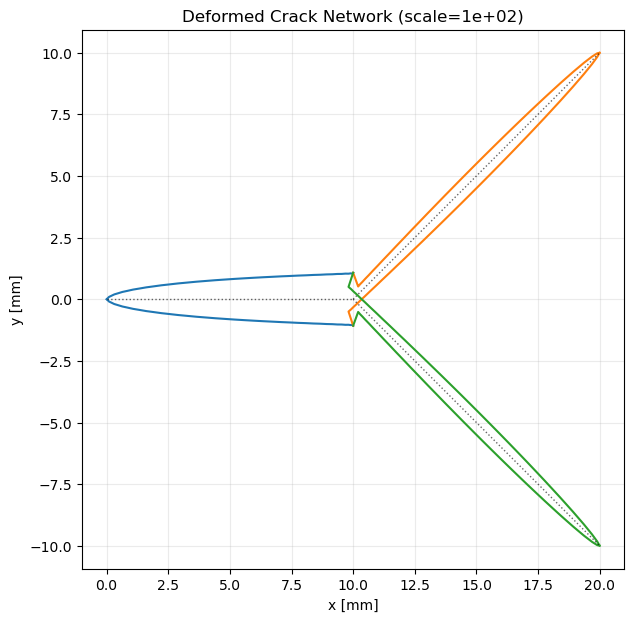

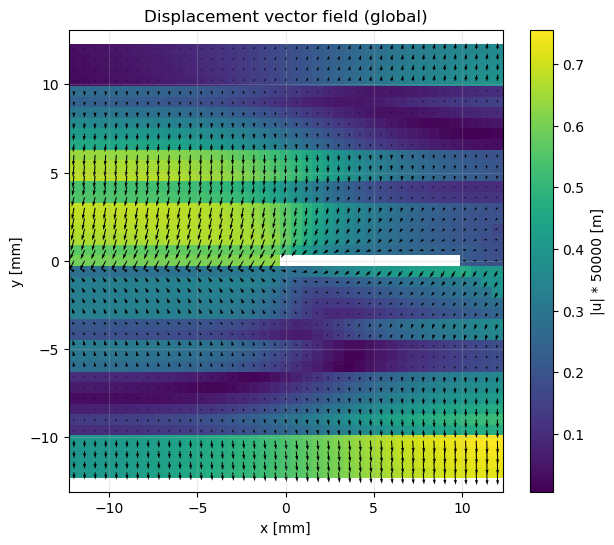

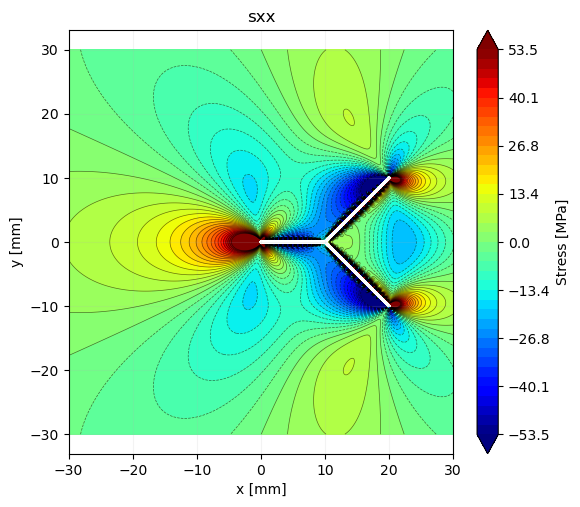

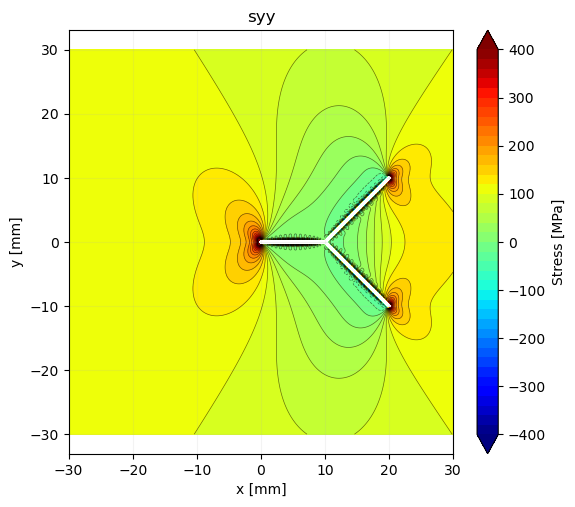

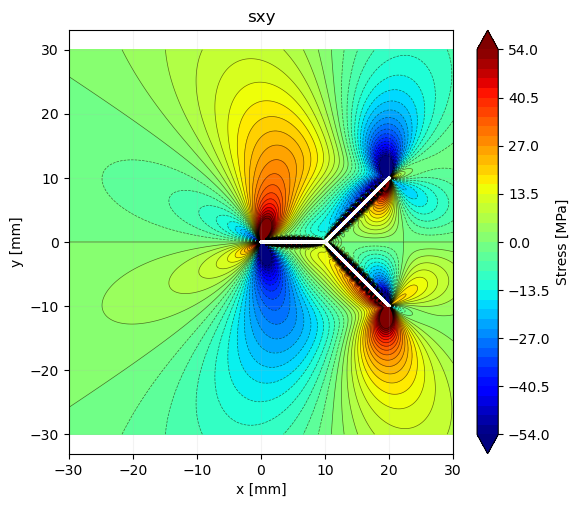

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Y-junction


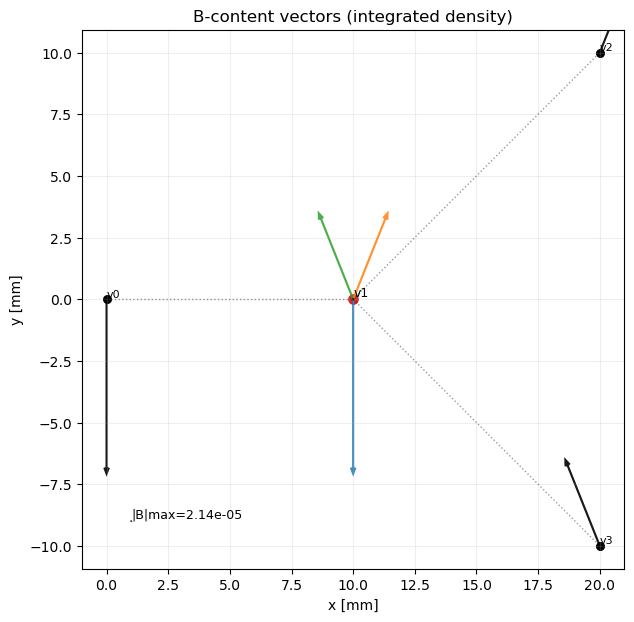

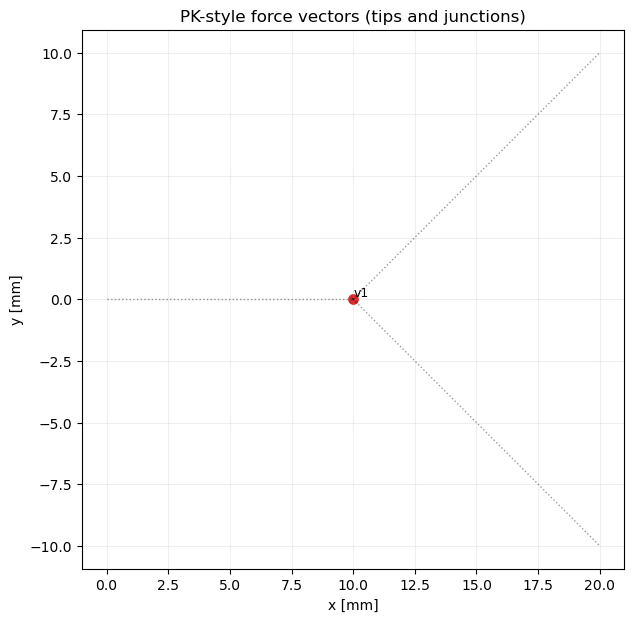

In [ ]:

import preamble as preamble
preamble.enable_autoreload()

# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Y-junction")
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# crack definition (2 segments in a chain: v0--v1--v2)
# units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 (left end)
    [1,  10.0*mm,  0.0*mm],   # v1 (kink / interior vertex, degree 2)
    [2,  20.0*mm,  10*mm],   # v2 (right end)
    [3,  20.0*mm,  -10*mm],   # v3 (extra vertex, not used)
], dtype=float)

connectivity = np.array([
    [0, 1],   # e0
    [1, 2],   # e1
    [1, 3]
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=100e6, sigma_xy=0e6)

calc = DCENetworkStaticV4(material, net, applied)

# -------------------------
# Parametrized crack solve (no COD=0 enforced at the interior degree-2 vertex)
# -------------------------
sol = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,   # OK to keep; ignored by the delegated single-crack solve
    n_int=96,
    crack_mode="half"
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Deformed crack network
plotter.plot_deformed_network(scale=1e2, n_pts_per_edge=800, 
                              show_faces=True, cod_smooth_window=5)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=True,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=True,
    mask_width_factor=1e-4,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=4
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)

# (2) B-content vectors (kinematic integrated density; your “B” diagnostic)
pkplt = DCEPlotterPK(res, out_dir=out_dir)

fig = pkplt.plot_b_content_vectors(
    style=VecPlotStyle(max_len_factor=0.18),  # optional
    user_scale=2e-3,                           # <-- single knob for arrow size
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

# (3) PK-style forces (stress-based; requires stress evaluator)
fig = pkplt.plot_pk_force_vectors(
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1.0,
    units="mm",
    exclude_self=True,     # needs res.stress_field_global_excluding(...)
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

